# Proyecto Integrador de Aprendizaje Automático

Para el mercado de autos usados el precio de un vehículo dependen de múltiples factores. Con el uso de técnicas de Machine Learning vamos a construir modelos predictivos capaces de estimar el precio de un vehículo en función de sus características y saber si tendrá alta o baja demanda. 
Por ello, vamos a implementar modelos de regresión y clasificación supervisada, utilizando Ridge y Lasso, así como regresión logística. A través de un flujo completo con Pipeline y ajuste de hiperparámetros con GridSearchCV, se busca garantizar soluciones generalizables.

Esto va a ser de gran ayuda pues para los compradores y vendedores tomar decisiones rápidas y acertadas resultan importantes para evaluar de manera precisa el valor de un automóvil y su potencial. 
Por ello, este proyecto tiene un impacto práctico en tal pues ofrece predicciones útiles para la toma de decisiones estratégicas.


Para ello, iniciamos importando las librerias que necesitamos

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Leemos nuestro dataset sugerido

In [141]:
dataset = pd.read_csv('vehicles.csv', sep=',')

El tamaño de nuestro dataset:

In [142]:
print("Dimensiones:", dataset.shape)

Dimensiones: (426880, 26)


Revisamos las primeras 5 filas del dataset:

In [143]:
dataset.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Las 5 últimas filas:

In [144]:
dataset.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


Vemos que siguen en orden la información. Ahora vemos la naturaleza de los datos:

In [145]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

Vemos que hay 7 variables numéricas y 19 variables categóricas. Aplicando esta función vemos que puede haber presencia de datos faltantes, por ello vamos a ver en qué variables se están presentando dichos faltantes.

In [146]:
dataset.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [148]:
dataset.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

Nos damos cuenta que en la variable County, que está mal escrita, está llena de datos faltantes, y al no ser relevante en el estudio, es mejor eliminarla. También la variable de tamaño hay más del 70% de nulos y en VIN hay 37% de nulos.
Para el url de la imagen, descripción y fecha de publicación tienen muy pocos nulos, por lo que no implican un peligro en los siguientes pasos para nuestro EDA. Y las variables como id, url, y el url de la región se podrían categorizar como irrelevantes, por lo que se pueden eliminar.

Para variables numéricas como el año y el odómetro hay aprox. un 0.3% a 1% de datos faltantes, por lo que será mejor imputar con la mediana de estas mismas. Para la latitud  y la longitud se presenta un porcentaje de 1.5%, por lo que también se pueden imputar con la mediana.

Para las variables categóricas, como la manufactura, con un 4% de nulos, el modelo, con un 1.2% de nulos, el combustible, con un 0.7% de nulos, el título de estado, con un 2% de nulos, y la transmisión, con un 0.6% de nulos, se deben imputar con la moda. En las variables de condición, con un 41% de nulos se podría, el cilindraje, la conducción y el color de la puntura, o imputarlas con desconocido (unknown), o eliminarlas.

Por ello, al haber presencia de datos faltantes en la mayoría de variables, iniciamos su tratamiento para luego verificar distribución después de imputar para analizar si no se distorsionaron los datos.

In [149]:
total_registros = len(dataset)
faltantes_por_columna = dataset.isnull().sum()
porcentaje_faltantes = (faltantes_por_columna / total_registros) * 100
analisis_faltantes = pd.DataFrame({
    'Valores_Faltantes': faltantes_por_columna,
    'Porcentaje_Faltantes': porcentaje_faltantes
})
print("Análisis de faltantes:")
print(analisis_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))
variables_eliminar_faltantes = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] > 40].index.tolist()
variables_imputar = analisis_faltantes[(analisis_faltantes['Porcentaje_Faltantes'] > 0) & 
                                     (analisis_faltantes['Porcentaje_Faltantes'] <= 40)].index.tolist()
variables_limpias = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] == 0].index.tolist()

print(f"Podemos eliminar esta (s) variables pues tiene un porcentaje aprox. mayor a 40% de faltantes: {len(variables_eliminar_faltantes)} variables")
print(f"Podemos hacer proceso de imputación con esta (s) variables pues tiene un porcentaja aprox. entre 0-40% de faltantes: {len(variables_imputar)} variables")
print(f"Variables limpias pues tienen un porcentaje de 0% de faltantes: {len(variables_limpias)} variables")

Análisis de faltantes:
              Valores_Faltantes  Porcentaje_Faltantes
county                   426880            100.000000
size                     306361             71.767476
cylinders                177678             41.622470
condition                174104             40.785232
VIN                      161042             37.725356
drive                    130567             30.586347
paint_color              130203             30.501078
type                      92858             21.752717
manufacturer              17646              4.133714
title_status               8242              1.930753
lat                        6549              1.534155
long                       6549              1.534155
model                      5277              1.236179
odometer                   4400              1.030735
fuel                       3013              0.705819
transmission               2556              0.598763
year                       1205              0.282281
descr

Con las variables identificadas según su porcentaje de datos faltantes, empezamos con el tratamiento:

Primero, estudiamos las variables que para nuestro estudio pueden ser irrelevantes:

In [150]:
def identificar_variables_irrelevantes(dataset):
    variables_irrelevantes = [
        'id', 'url', 'region_url', 'image_url', 'description',
        'posting_date', 'VIN', 'county', 'lat', 'long'
    ]
    return [col for col in variables_irrelevantes if col in dataset.columns]

variables_irrelevantes = identificar_variables_irrelevantes(dataset)

print("Variables irrelevantes:")
for i, col in enumerate(variables_irrelevantes, 1):
    print(f"{i}. {col}")

Variables irrelevantes:
1. id
2. url
3. region_url
4. image_url
5. description
6. posting_date
7. VIN
8. county
9. lat
10. long


Identificando hasta ahora estas variables, se escogieron por la gran cantidad de datos faltantes que tienen y su relevancia en el estudio, algunas no tienen un sentido en cuanto a la compra y venta de carros usados, o el hecho de que no son importantes para la toma de decisiones. Una de las variables que estudiamos a fondo para eliminarla fue el cilindraje. Es una caracteristica importante en los vehículos nuevos pues es una medida que indica el volumen total de los cilindros de un motor, lo cual le da mayor potencia y la eficiencia del combustible. Pero al ser este estudio en carros que ya fueron usados, y así mismo, su cilindraje ha cambiado. Estudiar esa variable no tendría un sentido dado ya que al ser usado la potencia y la eficiencia del combustible ya no será la misma, y dependerá más del estado del motor que el propio cilindraje. Por lo que procedemos a su eliminación. Este tipo de reflexiones las hicimos en las demás variables que aparecen en la lista, así sus eliminaciones harán la base esté limpia y en función al objetivo que estamos buscando:

In [151]:
todas_variables_eliminar = list(set(variables_eliminar_faltantes + variables_irrelevantes))
for i, var in enumerate(todas_variables_eliminar, 1):
    print(f"{i}. {var}")

print(f"\nDimensiones antes de eliminar: {dataset.shape}")
dataset_clean = dataset.drop(columns=todas_variables_eliminar, errors='ignore')

print(f"Dimensiones después de eliminar: {dataset_clean.shape}")

1. size
2. image_url
3. long
4. VIN
5. region_url
6. posting_date
7. id
8. lat
9. county
10. cylinders
11. condition
12. description
13. url

Dimensiones antes de eliminar: (426880, 26)
Dimensiones después de eliminar: (426880, 13)


También se encontró datos que son inválidos en el estudio que pudieron ser por un error de escritura pues habían valores imposibles que, en un contexto real serían exageradamente imposibles, y se encontraron en las variables de año y el precio del vehículo. Por ello vamos a filtrarlos con el rango correcto:

In [156]:
print(f"Registros antes de filtrar: {len(dataset_clean)}")
precios_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['price'] > 500) & (dataset_clean['price'] < 100000)]
precios_despues = len(dataset_clean)
print(f"• Precios válidos: {precios_despues} registros ({precios_antes - precios_despues} eliminados)")
años_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['year'] >= 1980) & (dataset_clean['year'] <= 2022)]
años_despues = len(dataset_clean)
print(f"• Años válidos: {años_despues} registros ({años_antes - años_despues} eliminados)")

print(f"\nRegistros después de filtrar: {len(dataset_clean)}")

Registros antes de filtrar: 373973
• Precios válidos: 373973 registros (0 eliminados)
• Años válidos: 373973 registros (0 eliminados)

Registros después de filtrar: 373973


Con estas variables eliminadas, re-analizamos nuestra base:

In [157]:
faltantes_despues_limpieza = dataset_clean.isnull().sum()
porcentaje_faltantes_despues = (faltantes_despues_limpieza / len(dataset_clean)) * 100

analisis_despues = pd.DataFrame({
    'Valores_Faltantes': faltantes_despues_limpieza,
    'Porcentaje_Faltantes': porcentaje_faltantes_despues
})

variables_con_faltantes = analisis_despues[analisis_despues['Valores_Faltantes'] > 0]
print("Después de la limpieza:")
print(variables_con_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))

Después de la limpieza:
              Valores_Faltantes  Porcentaje_Faltantes
drive                    112893             30.187473
paint_color              107465             28.736032
type                      78700             21.044300
manufacturer              12428              3.323235
title_status               6675              1.784888
model                      3623              0.968787
fuel                       2317              0.619563
odometer                   2032              0.543355
transmission               1744              0.466344


Vemos ahora un porcentaje que no afecta la continuidad de nuestro estudio. Como vamos a usar Pipeline y modelos que en su construcción imputan las variables numéricas y categóricas de acuerdo a sus características, dejamos hasta aquí la limpieza.

In [158]:
dataset_clean['HighDemand'] = (dataset_clean['price'] > dataset_clean['price'].median()).astype(int)

Vemos cómo quedan:

In [159]:
print(f"Dimensión: {dataset_clean.shape}")
print(f"Rango de precios: ${dataset_clean['price'].min():,} - ${dataset_clean['price'].max():,}")
print(f"Años: {int(dataset_clean['year'].min())} - {int(dataset_clean['year'].max())}")
print(f"HighDemand: {dataset_clean['HighDemand'].value_counts().to_dict()}")

Dimensión: (373973, 14)
Rango de precios: $501 - $99,999
Años: 1980 - 2022
HighDemand: {0: 187140, 1: 186833}


Con esta base tratada para datos faltantes, hacemos un pequeño chequeo de sus características y vemos las distribuciones de nuestros datos para iniciar con el EDA.

In [160]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373973 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        373973 non-null  object 
 1   price         373973 non-null  int64  
 2   year          373973 non-null  float64
 3   manufacturer  361545 non-null  object 
 4   model         370350 non-null  object 
 5   fuel          371656 non-null  object 
 6   odometer      371941 non-null  float64
 7   title_status  367298 non-null  object 
 8   transmission  372229 non-null  object 
 9   drive         261080 non-null  object 
 10  type          295273 non-null  object 
 11  paint_color   266508 non-null  object 
 12  state         373973 non-null  object 
 13  HighDemand    373973 non-null  int32  
dtypes: float64(2), int32(1), int64(1), object(10)
memory usage: 41.4+ MB


In [161]:
dataset_clean.describe()

,price,year,odometer,HighDemand
count,373973.000000,373973.000000,3.719410e+05,373973.000000
mean,19164.113075,2011.986020,9.752785e+04,0.499590
std,14277.339280,6.404836,1.443943e+05,0.500001
min,501.000000,1980.000000,0.000000e+00,0.000000
25%,7900.000000,2008.000000,3.921900e+04,0.000000
50%,15950.000000,2013.000000,8.900000e+04,0.000000
75%,27990.000000,2017.000000,1.372070e+05,1.000000
max,99999.000000,2022.000000,1.000000e+07,1.000000


También analizamos las distribuciones de las variables numéricas para ver su comportamiento puesto que están nuestras variables de interes:


Distribución de variables numéricas:


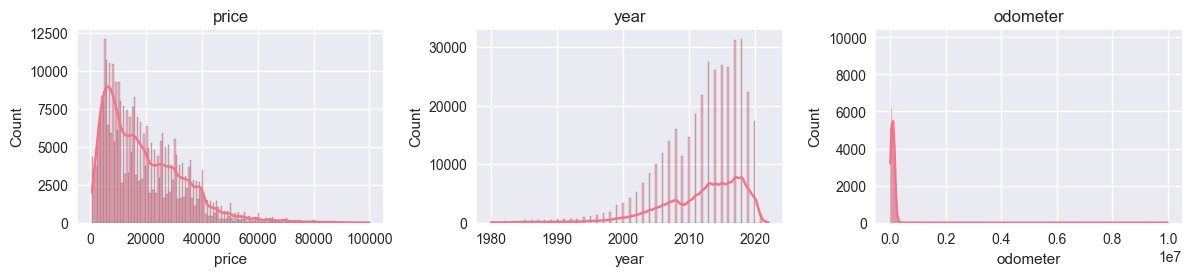

In [162]:
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns.tolist() 
print("\nDistribución de variables numéricas:")
chunk_size = 30
for j in range(0, len(numeric_cols), chunk_size):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numeric_cols[j:j+chunk_size]):
        plt.subplot(6, 5, i+1)
        sns.histplot(dataset_clean[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

Visualizando estas distribuciones encontramos para la variable de los precios muestra que la mayoría de los autos se concentran entre $0 y $40,000 dólares, y los más caros llegan a costar hasta $100,000 de dólares. 
Para la distribución de los años vemos que es aprox. normal y centrada alrededor de 2010-2015. Hay pocos carros antiguos pues aumenta hacia años más recientes.
Y para el kilometraje se ve que la gran mayoría de los carros tiene menos de 200,000 km recorridos, pero se ve un valro extremo con más de 1,000,000 km de recorrido, por lo que hay presencia de atípicos

Por ello, vamos a revisar graficamente mediante boxplots las distribuciones de estos atípicos:

Número de columnas numéricas: 3
Columnas numéricas: ['price', 'year', 'odometer']


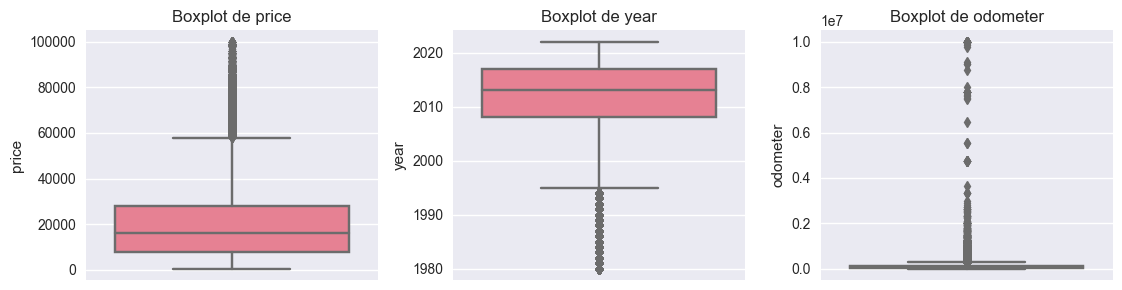

In [163]:
def plot_outliers(dataset_clean, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.boxplot(y=dataset_clean[col])
        plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Número de columnas numéricas: {len(numeric_cols)}")
print("Columnas numéricas:", list(numeric_cols))
plot_outliers(dataset_clean, numeric_cols)

Mediante la visualización de estos boxplots podemos ver, para la distribución de precios, los atípicos están por encima de $40,000 dólares, que representan carros que podrían ser de lujo. La mediana está alrededor de $15,000 a 20,000 dólares, es decir, la mitad de los carros vale menos que eso.
Para la variable año, la mitad de los carros salieron entre lo años 2008 a 2017 aprox. Los atípicos están por debajo del año 1995, siendo carro con más de 25 años. Y la mediana está alrededor de 2013, por lo que la mitad de los carros son de 2013 o más nuevos.
Y para el kilometraje la mayoría de los carros tiene menos de 200,000 km recorridos, pero con atípicos de más de 1,000,000+ km.

Al ver visualmente esta presencia de atípicos, hacemos una prueba de normalidad con Kolmogrov:

In [164]:
from scipy.stats import kstest
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns
results = []

for col in numeric_cols:
    data = dataset_clean[col].dropna()  
    if len(data) > 0:  
        mean, std = data.mean(), data.std()
        ks_stat, p_value = kstest(data, 'norm', args=(mean, std))
        
        results.append({
            'Variable': col,
            'N muestras': len(data),
            'KS Statistic': ks_stat,
            'p-value': p_value,
            'Normal (α=0.05)': p_value > 0.05
        })
results_df = pd.DataFrame(results)
print("\n=== Resultados KS (Datos Originales, sin Imputación) ===")
print(results_df.to_string(index=False))
non_normal_vars = results_df[results_df['Normal (α=0.05)'] == False]['Variable'].tolist()
print("\nVariables NO normales (p < 0.05):", non_normal_vars)


=== Resultados KS (Datos Originales, sin Imputación) ===
Variable  N muestras  KS Statistic  p-value  Normal (α=0.05)
   price      373973      0.102130      0.0            False
    year      373973      0.127249      0.0            False
odometer      371941      0.249702      0.0            False

Variables NO normales (p < 0.05): ['price', 'year', 'odometer']


Al haber presencia de datos atípicos y no tiener una distribución normal, hacemos tratamiento de estos con RobustScaler:

Estadísticas con RobustScaler:
            year   odometer      price
count  373973.00  371941.00  373973.00
mean       -0.11       0.09       0.16
std         0.71       1.47       0.71
min        -3.67      -0.91      -0.77
25%        -0.56      -0.51      -0.40
50%         0.00       0.00       0.00
75%         0.44       0.49       0.60
max         1.00     101.15       4.18


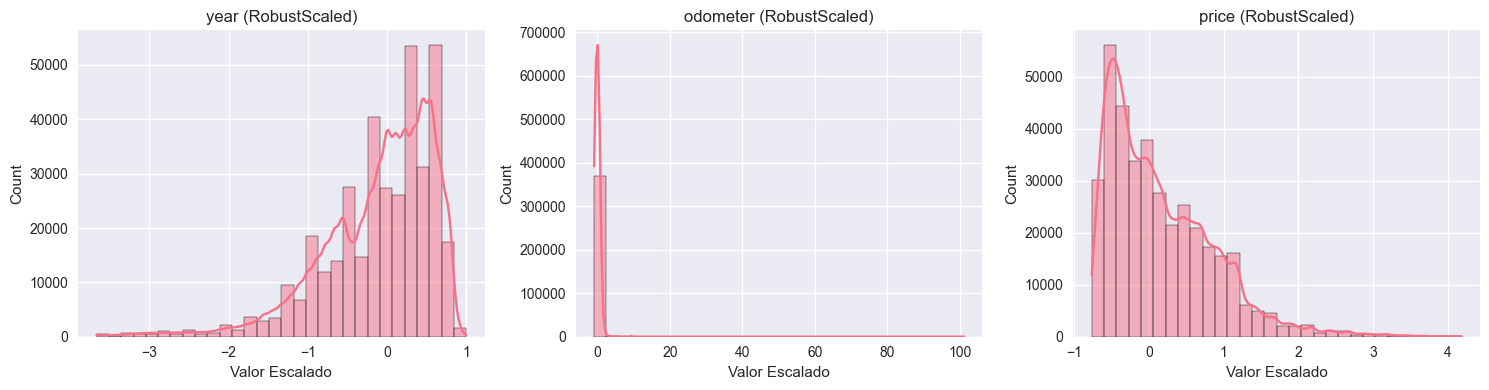

In [165]:
from sklearn.preprocessing import RobustScaler
numeric_features = ['year', 'odometer', 'price']

robust_scaler = RobustScaler()
dataset_robust = dataset_clean.copy()
dataset_robust[numeric_features] = robust_scaler.fit_transform(dataset_clean[numeric_features])

print("Estadísticas con RobustScaler:")
print(dataset_robust[numeric_features].describe().round(2))
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(dataset_robust[col], bins=30, kde=True)
    plt.title(f'{col} (RobustScaled)')
    plt.xlabel('Valor Escalado')

plt.tight_layout()
plt.show()

Con este tratamiento podemos analizar que los años están bien escalados y centrados, y en los precios se manejaron estos valores altos, como las gamas premium, y pueden ser manejables a lo largo del estudio.
Pero para el kilometraje se necesita manejar los errores de datos como 10M km, pues es algo imposible para este estudio, por lo que tuvimos que hacer otro filtro para esta variable.

In [118]:
dataset_clean = dataset_clean[dataset_clean['odometer'] <= 500000] 
robust_scaler = RobustScaler()
dataset_clean[['year', 'odometer', 'price']] = robust_scaler.fit_transform(
    dataset_clean[['year', 'odometer', 'price']]
)

print(f"Datos restantes: {len(dataset_clean):,}")
print(f"Kilometraje máximo: {dataset_clean['odometer'].max():.2f} (escalado)")
print(f"Kilometraje mínimo: {dataset_clean['odometer'].min():.2f} (escalado)")
print(f"Medianas escaladas: year={dataset_clean['year'].median():.2f}, "
      f"odometer={dataset_clean['odometer'].median():.2f}, "
      f"price={dataset_clean['price'].median():.2f}")


Datos restantes: 371,068
Kilometraje máximo: 4.20 (escalado)
Kilometraje mínimo: -0.91 (escalado)
Medianas escaladas: year=0.00, odometer=0.00, price=0.00


Ya con este re ajuste tenemos los atípicos en un rango manejable.

Por ello, empezamos analizar las correlaciones entre estas variables.

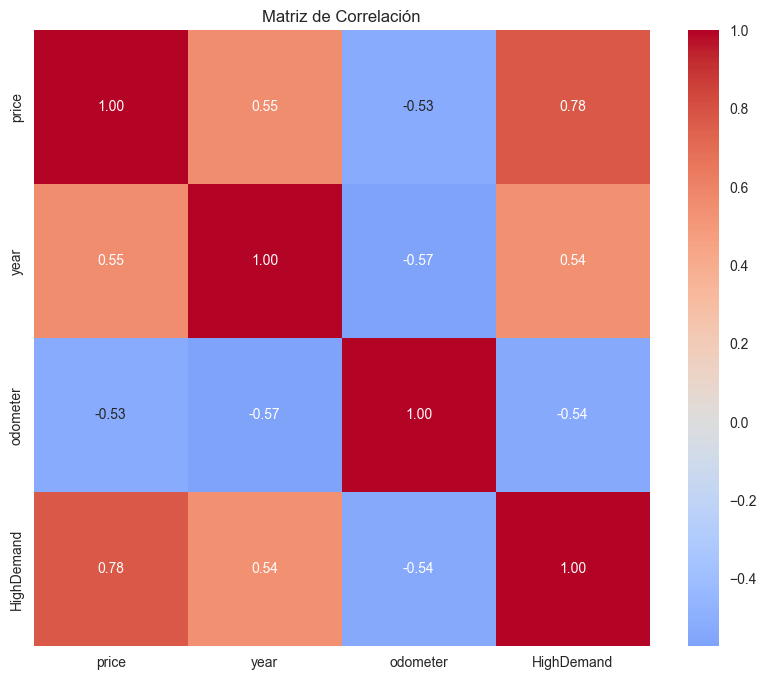

In [119]:
numeric_vars = ['price', 'year', 'odometer', 'HighDemand']
correlation_matrix = dataset_clean[numeric_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


Analizamos que, para la relación entre año y precio hay correlación positiva, es decir, los carros más nuevos tienden a ser más caros. También entre kilometraje y el precio hay una correlación negativa, por lo que nos diría que los carros con más kilometraje tienden a ser más baratos pues al ser alto ese kilometraje significa más uso por el dueño pasado. Y los carros con más kilometraje tienden a tener menor demanda.

Entre la alta demanda y precio tienen una correlación positiva, es decir, los carros con alta demanda son más caros.

Entre los años y el kilometraje tienen una correlación negativa moderada pues los carros más nuevos tienden a tener menos kilometraje, y relacionandolo con la alta demanda, los carros más nuevos tienden a tener alta demanda.

Todas las variables tienen correlaciones moderadas entre los predictores.

Ahora mediante el VIF vemos más a fondo las variables que tienen una diferencia significativas entre sus grupos.

In [120]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def analisis_vif_conciso(df, target_name):
    X = df.drop(columns=[target_name]).select_dtypes(include=[np.number])
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_df = vif_df.sort_values('VIF', ascending=False)
    vif_df["Estado"] = vif_df["VIF"].apply(lambda x: 
        "Normal" if x < 5 else "Moderado" if x < 10 else "Alto")
    
    return vif_df

print("Análisis para regresión con la variable precio")
print("-" * 40)
vif_regresion = analisis_vif_conciso(dataset_clean, "price")
print(vif_regresion.to_string(index=False))
print(f"Total variables: {len(vif_regresion)}")
 
print("Análisis para clasificación con la variable HighDemand")
print("-" * 40)
vif_clasificacion = analisis_vif_conciso(dataset_clean, "HighDemand")
print(vif_clasificacion.to_string(index=False))
print(f"Total variables: {len(vif_clasificacion)}")

Análisis para regresión con la variable precio
----------------------------------------
  Variable      VIF Estado
  odometer 1.566361 Normal
      year 1.514834 Normal
HighDemand 1.129601 Normal
Total variables: 3
Análisis para clasificación con la variable HighDemand
----------------------------------------
Variable      VIF Estado
    year 1.646511 Normal
odometer 1.639817 Normal
   price 1.462401 Normal
Total variables: 3


Los resultados nos muestran que no hay multicolinealidad en los datos pues todos los VIF están muy por debajo de 5. Nos da un camino libre para ejecutar nuestros modelos de manera correcta.

Y para finalizar con el EDA, empezamos un análisis minucioso acerca de las relaciones y distribuciones de todas la variables. Primero, un análisis univariado:

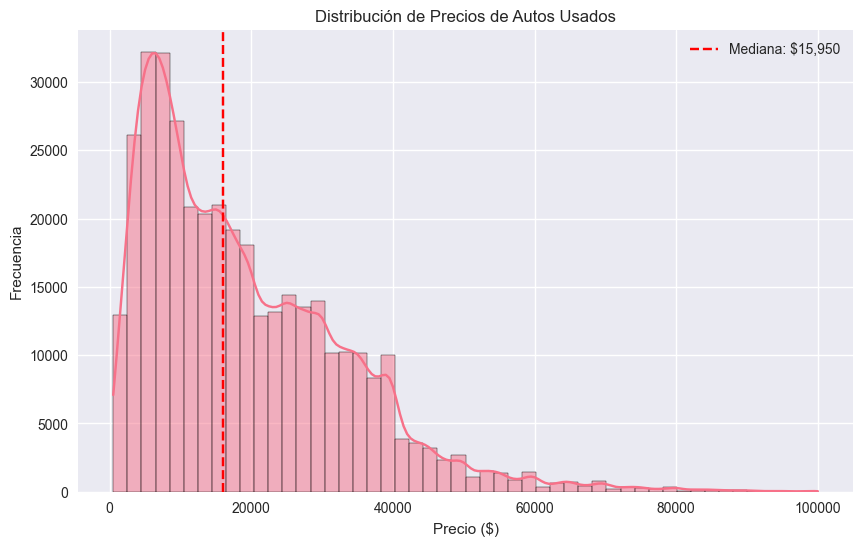

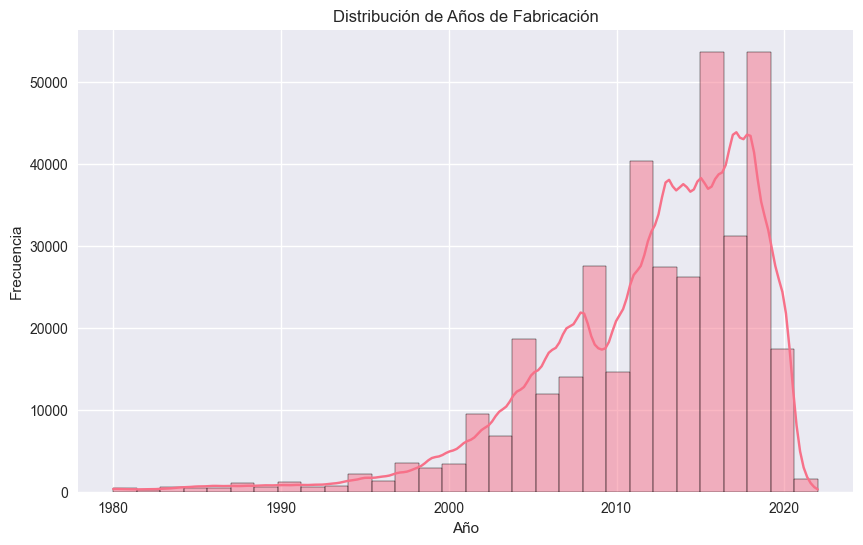

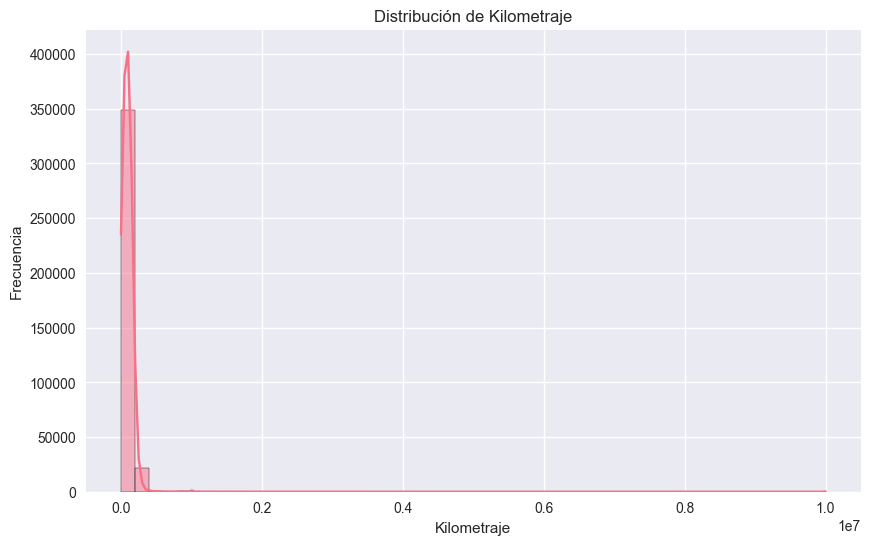

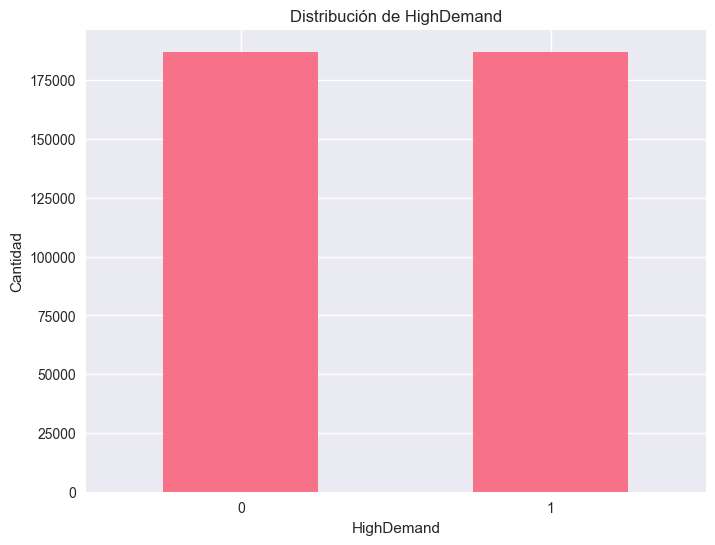

In [166]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl") 
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['price'], bins=50, kde=True)
plt.title('Distribución de Precios de Autos Usados')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.axvline(dataset_clean['price'].median(), color='red', linestyle='--', 
            label=f'Mediana: ${dataset_clean["price"].median():,.0f}')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['year'], bins=30, kde=True)
plt.title('Distribución de Años de Fabricación')
plt.xlabel('Año')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['odometer'], bins=50, kde=True)
plt.title('Distribución de Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(8, 6))
dataset_clean['HighDemand'].value_counts().plot(kind='bar')
plt.title('Distribución de HighDemand')
plt.xlabel('HighDemand')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

Para la primera gráfica observamos que la gran mayoría de los carros usados tienen precios por debajo de los $20,000 dólares, y la mitad de los carros se venden por menos de $15,950 dólares, es decir, son pocos los carros caros que se venden por su alto costo.

Para la segunda gráfica de distribución de años de fabricación vemos que hay muy pocos carros de las décadas de 1980 y 1990 en el dataset, pero aumentan a partir del año 2000, por lo que los carros usados que se venden son relativamente modernos. Pudiera decir que los carros más viejos ya se han chatarreado y son difíciles de vender. 

Para la tercera gráfica de distribución de kilometraje muestra que los carros usados tienden a venderse en rangos de kilometraje como de 30,000 a 40,000 km, 70,000 a 80,000 km, o 140,000 a 150,000 km. Esto se puede interpretar en la manera de que, si el carro esttá en período de garantía o un mantenimiento mayor, las personas tienden a vender el carro para más ganancias.

Y la última gráfica de distribución de HighDemand muestra que, aproximadamente entre el 60% y el 70% de los carros están etiquetados como de Alta Demanda, es decir, la mayoría se consideran populares, se podrían venden más rápido o tienen un precio más firme.

Luego de estos análisis, pasamos a uno bivariado:

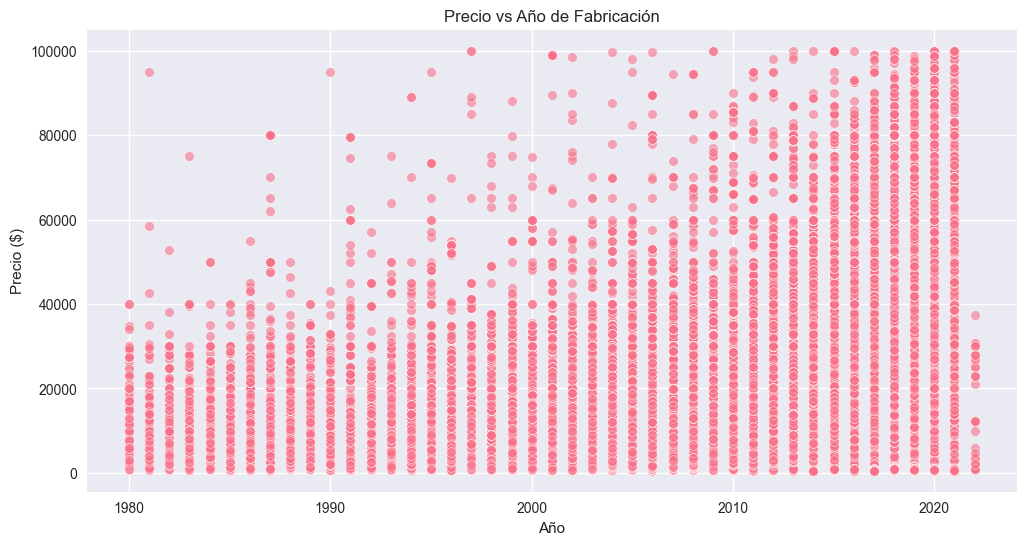

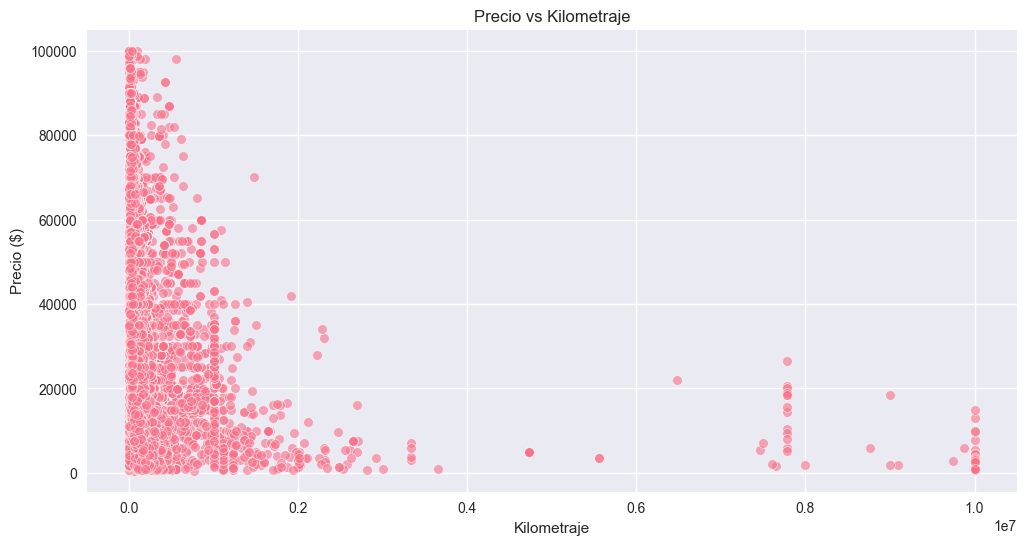

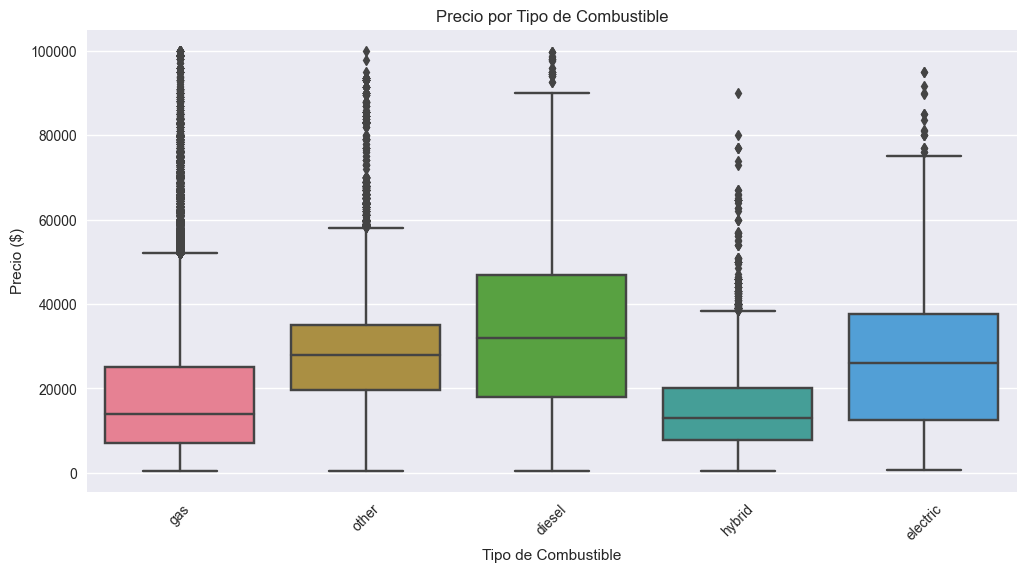

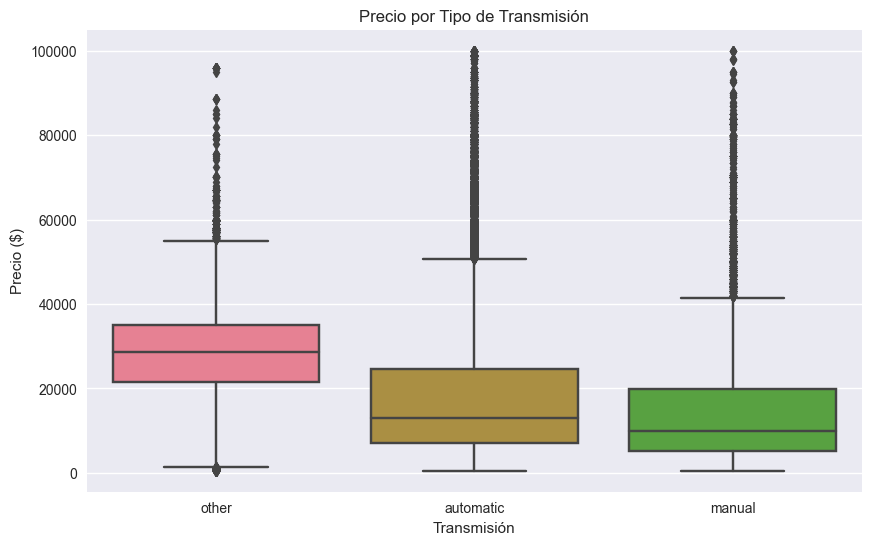

In [167]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='year', y='price', alpha=0.6)
plt.title('Precio vs Año de Fabricación')
plt.xlabel('Año')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='odometer', y='price', alpha=0.6)
plt.title('Precio vs Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=dataset_clean, x='fuel', y='price')
plt.title('Precio por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset_clean, x='transmission', y='price')
plt.title('Precio por Tipo de Transmisión')
plt.xlabel('Transmisión')
plt.ylabel('Precio ($)')
plt.show()

De acuerdo con lo visualizado, en el caso de la gráfica del precio con respecto al año de fabricación vemo que a medida que el año de fabricación es más reciente, el precio de venta aumenta pues los carros más nuevos valen significativamente más que los autos más viejos, con facotres como mejor tecnología, menos desgaste y más seguros para manejar. Y se tiene mucho en cuenta el año del modelo para determinar el precio del carro usado.

Para la relación de precio y kilometraje se muestra que un mayor kilometraje indicaría desgaste en el motor y otras partes del auto, lo que reduce su precio, por lo cual es clave para la valoración del carro usado.

Para la relación de precio por tipo de combustible muestra que los carros que usan el tipo de combustible 1, siendo los carros tipo eléctricos o híbrido", tienen un precio más alto que los carros que usan del tipo combustible 0, siendo la gasolina o diésel. Por ello, los vehículos como híbridos o eléctricos suelen tener un precio de venta alto, y en la gama de usado se refleja de igual manera

Para la relacion de precio por tipo de transmisión muestra que el tipo de transmisión, como las automáticas estándar añaden valor sobre las transmisiones manuales, con un precio casi similar, y las transmisiones avanzadas se encuentran en los carros más caros.

Análisis de tops

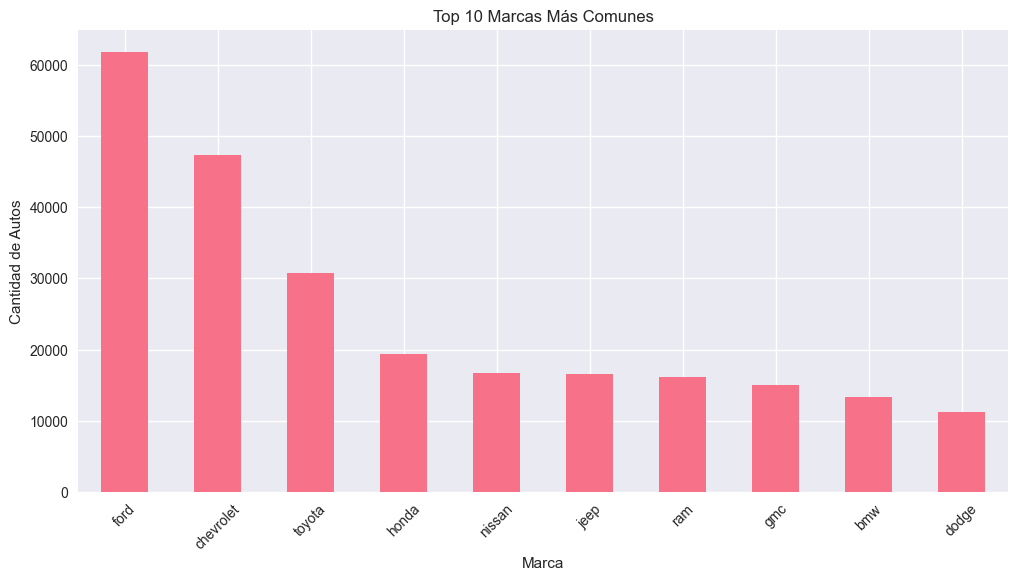

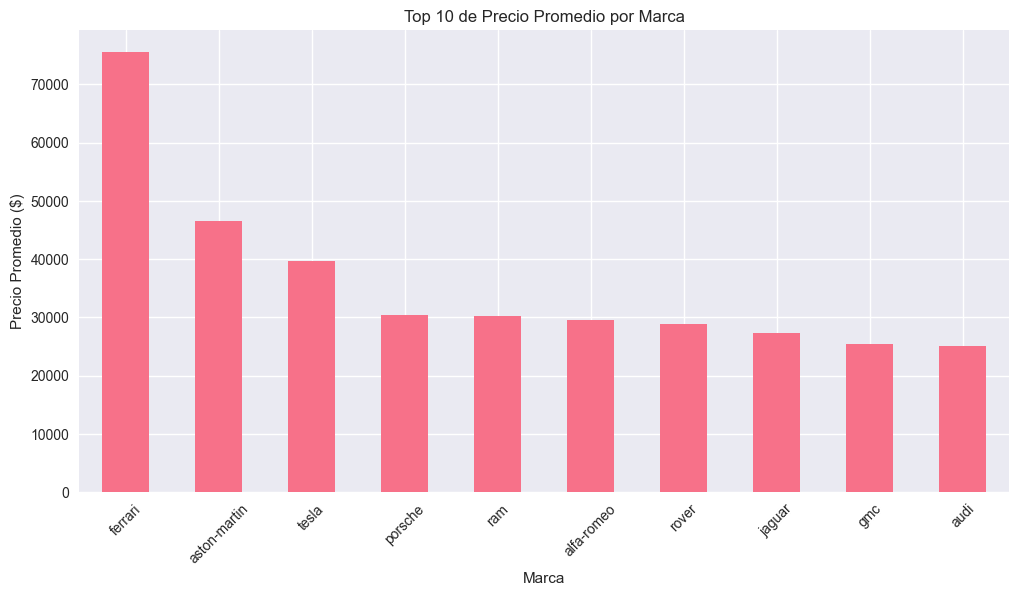

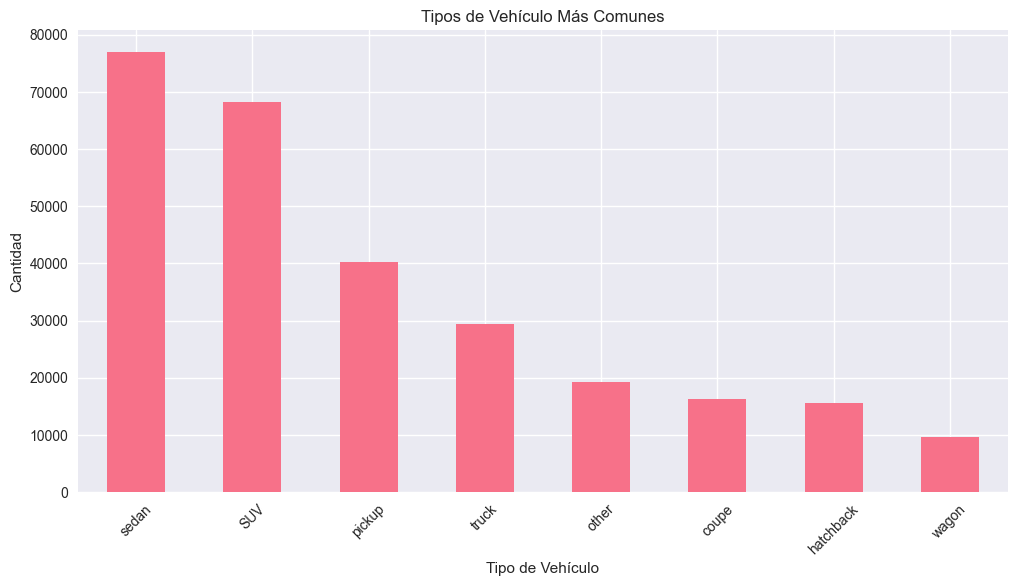

In [168]:
plt.figure(figsize=(12, 6))
top_10_brands = dataset_clean['manufacturer'].value_counts().head(10)
top_10_brands.plot(kind='bar')
plt.title('Top 10 Marcas Más Comunes')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Autos')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
price_by_brand = dataset_clean.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10)
price_by_brand.plot(kind='bar')
plt.title('Top 10 de Precio Promedio por Marca')
plt.xlabel('Marca')
plt.ylabel('Precio Promedio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
dataset_clean['type'].value_counts().head(8).plot(kind='bar')
plt.title('Tipos de Vehículo Más Comunes')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

import matplotlib.pyplot as plt
import seaborn as sns
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'model', 'fuel', 'transmission', 
                       'title_status', 'type', 'drive', 'paint_color', 'region', 'state']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


X = dataset_clean[numeric_features + categorical_features]
y_reg = dataset_clean['price']
y_clf = dataset_clean['HighDemand']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)


# Ridge
ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Lasso
lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

# Logistic Regression
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=500))
])

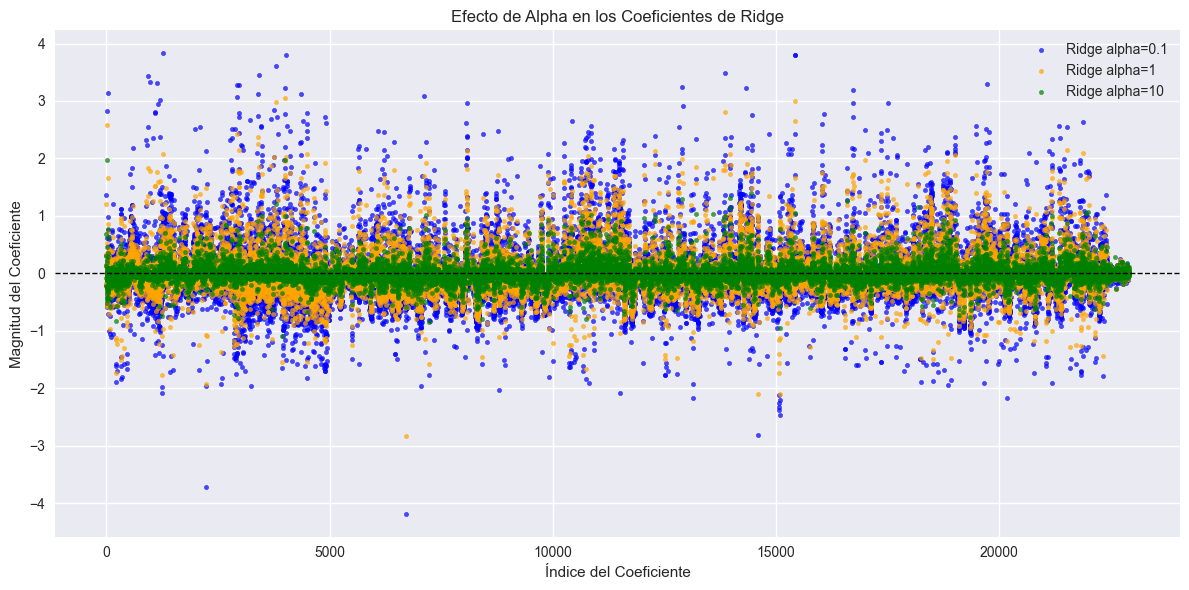

In [ ]:
alphas = [0.1, 1, 10]
coef_dict = {}

for alpha in alphas:
    ridge = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])
    ridge.fit(X_reg_train, y_reg_train)
    # Guardamos coeficientes (el modelo final está en ridge.named_steps['model'])
    coef_dict[alpha] = ridge.named_steps['model'].coef_

plt.figure(figsize=(12,6))
colors = {0.1: "blue", 1: "orange", 10: "green"}
for alpha, coefs in coef_dict.items():
    plt.scatter(range(len(coefs)), coefs, 
                s=10, alpha=0.7, 
                color=colors[alpha], 
                label=f'Ridge alpha={alpha}')

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Índice del Coeficiente")
plt.ylabel("Magnitud del Coeficiente")
plt.title("Efecto de Alpha en los Coeficientes de Ridge")
plt.legend()
plt.tight_layout()
plt.show()

Notamos que evaluamos los respectivos alphas, 0.1, 1 y 10.

Vemos que en caso de 10 se realiza una regularizacion fuerte, lo que hace que el modelo se simplifique mucho, esto puede hacer que haya underfitting.

Ahora con el Alpha 1 vemos que hay una regularizacion moderada, haciendo que el modelo sea mas estable y generalizable, al usar 1 suele ser el punto de equilibro entre los 3 alphas que usamos.

Ahora con Alpha 0.1 hay una regularizacion debil, aproximandose mas a una regresion lineal normal, con este alpha corremos el riesgo de sobreajustar los datos.

In [126]:
ridge_params = {'model__alpha': [0.1, 1, 10]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_reg_train, y_reg_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['year',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'model',
                                                                          'fuel',
                                                                          'transmission',
                                                                          'title_status',
                                                                          'type',
                                                                          'drive',
                                                                          'paint_color',
                                                                          'region',
                                                                          'state'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1, 10]}, scoring='r2')

In [127]:
print("Mejor Ridge alpha:", ridge_grid.best_params_)

Mejor Ridge alpha: {'model__alpha': 0.1}


Luego de aplicar GridSearch, el cual hace es probar varias combinaciones de parametros, en este caso alphas, para cada combinacion y entrena el modelo y evalua su desempeño utilizando validacion cruzada, notamos que el mejor Alpha que nos ofrecio fue el de 0.1.

In [128]:
y_pred_ridge = ridge_grid.predict(X_reg_test)

In [129]:
print("\nRidge:")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_ridge))
print("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge)))
print("R²:", r2_score(y_reg_test, y_pred_ridge))


Ridge:
MAE: 0.1839134745573639
RMSE 0.30903764905488007
R²: 0.8087661600028073


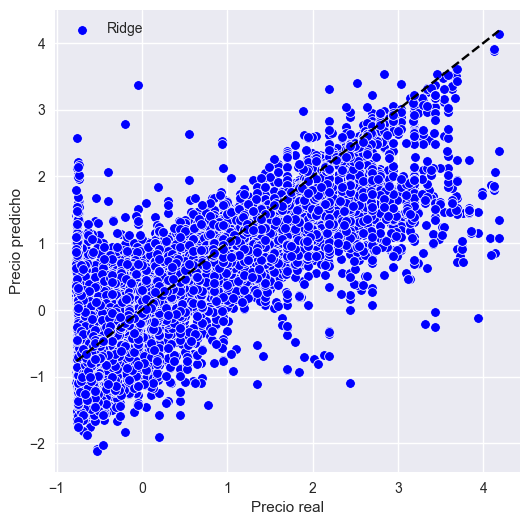

In [130]:
# Gráfico valores reales vs predichos (solo Ridge)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_reg_test, y=y_pred_ridge, label="Ridge", color="blue")
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'k--')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.legend()
plt.show()

In [170]:
logreg_params = {'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

logreg_grid = GridSearchCV(logreg_pipe, logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_clf_train, y_clf_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['year',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'model',
                                                                          'fuel',
                                                                          'transmission',
                                                                          'title_status',
                                                                          'type',
                                                                          'drive',
                                                                          'paint_color',
                                                                          'region',
                                                                          'state'])])),
                                       ('model',
                                        LogisticRegression(max_iter=500))]),
             param_grid={'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                      1000]},
             scoring='accuracy')

In [171]:
print(logreg_grid.best_params_)

{'model__C': 1000}


In [172]:
y_pred = logreg_grid.best_estimator_.predict(X_clf_test)
y_proba = logreg_grid.best_estimator_.predict_proba(X_clf_test)[:, 1]  # probas clase positiva

# =============================
# 2. Métricas numéricas
# =============================
print("📊 Métricas en el conjunto de prueba:")
print("Accuracy:", accuracy_score(y_clf_test, y_pred))
print("Precision:", precision_score(y_clf_test, y_pred))
print("Recall:", recall_score(y_clf_test, y_pred))
print("F1-score:", f1_score(y_clf_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_clf_test, y_proba))

print("\nReporte completo:")
print(classification_report(y_clf_test, y_pred))

📊 Métricas en el conjunto de prueba:
Accuracy: 0.9310103215026815
Precision: 0.9336297581607201
Recall: 0.9279939635658079
F1-score: 0.9308033300897394
AUC-ROC: 0.9769847347327559

Reporte completo:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     37106
           1       0.93      0.93      0.93     37108

    accuracy                           0.93     74214
   macro avg       0.93      0.93      0.93     74214
weighted avg       0.93      0.93      0.93     74214

